# Deep Network Development, 2026 Spring - Homework 1

In this first homework assignment, you need to train and evaluate a simple Multi-layer Perceptron (MLP) neural network on a regression task and then, a classification task using the PyTorch library.

The homework consists of several subtasks (A - I) that build on one another. The assignment includes an automatic testing script that checks the correctness of your solutions for the individual subtasks. Therefore, **do not change the structure of the notebook**, do not split it into multiple parts, and do not modify the pre-written sections. Only enter your solutions in the appropriate places, otherwise we will not be able to grade your work. Your solutions must be written between the `# Implement your solution BELOW` and `# Implement your solution ABOVE` lines. If the message "Tester: .... OK" appears when you run the solved subtasks, the solution is _likely_ correct. However, the testing script cannot verify correctness in every aspect. Therefore, it is possible that after submission we may ask you to make additional corrections to your solution. Submitted homework assignments are checked by machine-learning-based plagiarism detection. If copying is suspected, both the copied solution(s) and the original solution(s) that inspired them may be rejected.

**!!! It is forbidden to publish the solutions to the tasks !!!**

If you get stuck, it is recommended to review the supporting notebooks and videos shared on Canvas, as well as the lecture materials. We collect frequently asked questions and answers on the Canvas forum under the title "Homework 1 - Frequently Asked Questions". You may also ask the instructors for help, for example via Microsoft Teams.

**Solution and submission procedure:**

The published Jupyter notebook containing the tasks was shared through Google Drive, so clicking the link opens Google's own Jupyter notebook editor and runtime environment, Google Colab. This allows the shared notebook to be edited and run online. Since the notebook is shared with "view" permissions only, Google Colab opens it in the so-called "Playground" mode, where the notebook can be edited and executed, but the changes will not be saved automatically. To edit the notebook in a persistent way, use one of the following options:
- It is recommended to download the notebook (the `.ipynb` file) and use it on your own computer in a Python environment with the `jupyterlab` package installed, since you will also need to work in such an environment during the Coding test. More information about this environment can be found on Canvas in the video "Development Environment Setup.mp4" and on the page "Development Environment Setup.pdf". The exact package versions which will be available during the Coding test are shared in the "requirements.txt" file, also on Canvas.

- If you would like to edit and run the notebook online in Google Colab, you need to make a copy of it in your own Drive storage (Google Colab File menu -> Save a copy in Drive), and then open that copy for editing. The resulting solution can then be downloaded and submitted. However, Google Colab will not be available during the Coding test.

The completed notebook containing your solution must be uploaded to Canvas as an `.ipynb` file via the homework submission page.
**Please do not modify the notebook structure and do not split it into multiple notebooks by task.**

**Deadline:** Tuesday, April 7, 2026, 23:59.

**Late submission deadline:** Tuesday, April 14, 2026, 23:59. - **This is the final deadline for submitting Homework 1. If you miss this, you cannot continue the course and thus cannot earn a grade this semester !!!**

**Assessment:** Correctly solving the homework and having it accepted by the instructors is a prerequisite for earning a grade on this course. The quality of the homework is not graded in detailed points; assessment is binary: pass / fail. A mostly correct and mostly complete ("pass") solution submitted by the first, normal deadline is worth 5 points. Solutions submitted following the first, normal deadline will not receive these 5 points.

**Requirement:** Wherever possible, we expect efficient, vectorized solutions. For further details, see Canvas, the "Homework 1 - Frequently Asked Questions" discussion, and the reply "Can I use Python loops?".


Downloading the tester script, imports.
*   If you are not working in Google Colab, the `!rm` and `!wget` commands below may not work. In that case, download the test script from the URL given in the cell below, then place it next to this notebook file!


In [1]:
# Download tester
# !rm dndmsc26spring_hw1_tester.py                                                                  # "!rm" might not work in all environments
# !wget nipg12.inf.elte.hu/~vavsaai@nipg.lab/dndmsc26spring/files/dndmsc26spring_hw1_tester.py      # "!wget" might not work in all environments
#                                                                                                   #     when using offline Jupyterlab/notebook environment, download and place tester script next to the notebook file

import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from dndmsc26spring_hw1_tester import Tester

###**A**: Loading the dataset

**Information about the dataset**:
The original dataset comes from the UCI Machine Learning Repository (http://archive.ics.uci.edu/ml/datasets/Student+Performance), which have been slightly modified. It contains data about students studying in two Portuguese secondary schools, including their third-period and final grades (0-20). In this homework, **we will use neural networks to estimate the students' school performance based on their social and financial background.**

The testing script downloads the dataset stored in text form and places it in the `content` string. Below, we print both its length and the first 500 characters of the string. Each line in the dataset file gives the values of the variables belonging to one sample. Within a line, the values corresponding to the individual variables are separated by semicolons. The first line of the dataset contains the variable names.

Your task is to **convert the `content` string into a NumPy array containing the values of the dataset variables.** The array data type must be `np.float32` (floating point). Store the variable values in the array `dataset_noisy` with shape `(n_samples, n_variables)`. We will separate the input variables and labels later.

The dataset contains missing values in some places: part of the data was not available when the dataset was recorded. More specifically, missing values occur in the columns describing the parents' occupations and the student's guardian. These are the ninth (`Mjob`), tenth (`Fjob`), and twelfth (`guardian`) columns. In the `content` string, missing values are absent between the corresponding semicolons, so in such cases two (or more) semicolons appear consecutively.

You must handle and detect the missing values while reading the data: the missing values must be represented by `np.nan` (Not-a-Number) values in the resulting `dataset_noisy` array.


In [2]:
tester = Tester()
content = tester.get_dataset_content()

print("Number of characters in dataset:", len(content))
print(content[:500])


Number of characters in dataset: 27418
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0;0;18;0;1;1;4;4;5;0;4;;2;2;0;0;1;1;1;0;0;1;1;4;3;4;1;1;3;6;14;15;15
0;0;17;0;1;0;1;1;5;3;4;1;1;2;0;1;0;1;1;1;0;0;1;5;3;3;1;1;3;4;6;6;7
0;0;15;0;0;0;1;1;5;;3;;1;2;3;0;1;0;1;0;0;0;1;4;3;2;2;3;3;10;7;7;8
0;0;15;0;1;0;4;2;1;4;0;;1;3;0;1;0;0;0;0;0;0;0;3;2;2;1;1;5;2;15;15;15
0


In [6]:
# implement your solution BELOW

from io import StringIO

dataset_noisy = np.genfromtxt(StringIO(content), delimiter = ';', skip_header = 1, dtype = np.float32)

# implement your solution ABOVE

tester.test('dataset_load', dataset_noisy)

Tester: Dataset loading OK


## **B**: Handling missing data

We will not be able to continue working with NaN values, because most NumPy/PyTorch operations do not support them, and for any array that contains at least one NaN value, the output of these operations will also become NaN, including for example our neural network's prediction and loss. The latter would prevent us from optimizing the network using gradient-based methods. Therefore, we will eliminate the NaN values representing missing data in the following way:

**For each variable that may contain NaN values, create a new variable indicating whether a valid value is present for that variable in the given sample or not.** If a valid value is present, the new variable should take the value 1; in the NaN case, it should take the value 0. Place the original data and the new variables into the `dataset` array: the columns of the new variables must be appended **after** all columns containing the original variables, in the appropriate order! The previous task description mentioned which columns may contain NaN values.</br>
Since columns (variables) with indices #8, #9, and #11 in our 33-variable dataset may contain NaN values, the new `dataset` array will have 36 variables, and the three new variables will be placed in the last three columns. For example, in column #33, a row should contain 0 if the same row in column #8 contains NaN, and 1 otherwise. Similarly, create columns #34 and #35 based on columns #9 and #11.

Finally, **replace all NaN values in the resulting array with zeros!**


In [34]:
# implement your solution BELOW

col33 = (~np.isnan(dataset_noisy[:,8])).astype(np.float32)
col34 = (~np.isnan(dataset_noisy[:,9])).astype(np.float32)
col35 = (~np.isnan(dataset_noisy[:,11])).astype(np.float32)


dataset = np.concatenate((dataset_noisy, col33[:, None], col34[:,None], col35[:,None]), axis = 1)
maskdataset = np.isnan(dataset)
dataset[maskdataset] = 0


# print()
# implement your solution ABOVE

tester.test('dataset_fill_missing', dataset)

Tester: Dataset fill missing OK


## **C**: Splitting into training, validation, and test sets

**Randomly shuffle the samples** in the `dataset` array. In general, this is advisable because the samples in the dataset may be ordered according to some property. Without shuffling, the label distributions in the resulting splits could differ significantly.

After that, **split the array into training, validation, and test sets** in a 50%, 25%, 25% ratio. Name the three arrays containing these sets `dataset_split_train`, `dataset_split_val`, and `dataset_split_test`, respectively!


In [37]:
# implement your solution BELOW

TRAINING_RATIO = 0.5
VAL_RATIO = 0.25
TEST_RATIO = 0.25

rng = np.random.default_rng()
rng.shuffle(dataset, axis = 0)

dataset_length = dataset.shape[0]
training_idx = int(dataset_length * TRAINING_RATIO)
val_idx = training_idx+int(dataset_length * VAL_RATIO)
test_idx = val_idx + int(dataset_length * TEST_RATIO)
dataset_split_train = dataset[:training_idx, :]
dataset_split_val = dataset[training_idx:val_idx, :]
dataset_split_test = dataset[val_idx:, :]



# implement your solution ABOVE

tester.test('dataset_split', dataset_split_train, dataset_split_val, dataset_split_test)

Tester: Dataset split OK


## **D**: Creating data iterators for the regression task

Gradient-based training of neural networks is most often implemented using iterators that traverse the dataset and produce the input and label batches required for training. In the regression task, the target label variable to be estimated will be the students' final grades (the column named `G3` in the original dataset text file, i.e. the column with index 32), while the input variables will be all other attributes, including the three newly created variables.

In this subtask, **you need to create three iterator objects** named `dataloader_reg_train`, `dataloader_reg_val`, and `dataloader_reg_test`, which traverse the arrays containing the training, validation, and test sets created in the previous subtask. **At each step, the iterators must return two tensors**, storing one batch of input data and one batch of label data, respectively. Therefore, the shapes of the returned tensors will be `(batch_size, 35)` and `(batch_size, 1)`. The latter tensor (containing the labels) will store the students' final grades, while the former will store the values of all other dataset variables for the corresponding samples. `batch_size` denotes the number of samples that our neural network receives at once in a single batch, for example 32.

It is important to emphasize that the iterators should already return sample batches derived from the above NumPy arrays (`np.ndarray`) as `torch.tensor` objects (more precisely, as two-element tuples containing `torch.tensor` objects), since training neural networks defined in PyTorch definitely requires PyTorch tensors. The tensors must use the **data type** 4-byte floating point, i.e. `torch.float32`.

The iterators enumerating the **training and validation sets must traverse their samples in random order**. The iterator enumerating the test set must not change the order of the `dataset_split_test` array!

The implementation of the iterators can be solved in several ways. For example, by creating a custom generator/iterator, or by using and possibly subclassing the `Dataset` and `DataLoader` classes from the `torch.utils.data` module.


In [40]:
# implement your solution BELOW

class customDataset(Dataset):
    def __init__(self, arr):
        self.arr = torch.as_tensor(arr, dtype=torch.float32)

    def __len__(self):
        return self.arr.shape[0]
    
    def __getitem__(self, idx):
        input_tensor = torch.cat((self.arr[idx, :32], self.arr[idx, 33:]))
        output_tensor = self.arr[idx, 32:33]
        return (input_tensor, output_tensor)

# implement your solution ABOVE

dataset_train = customDataset(dataset_split_train)
dataset_val = customDataset(dataset_split_val)
dataset_test = customDataset(dataset_split_test)


dataloader_reg_train = DataLoader(dataset_train, batch_size=32, shuffle = True)
dataloader_reg_val = DataLoader(dataset_val, batch_size=32, shuffle = True)
dataloader_reg_test = DataLoader(dataset_test, batch_size=32, shuffle = False)

tester.test('reg_iter', dataloader_reg_train, dataloader_reg_val, dataloader_reg_test)

Tester: Dataset iterators for regression task OK


## **E**: Defining the regression neural network

**Define the class implementing the neural network to be used for the regression task**, as a subclass of the general `torch.nn.Module` class, then instantiate it and assign the instance to the variable `reg_model`!

The regression neural network must **contain 3 fully connected layers with 25, 25, and 1 neurons, respectively, and apply the ReLU activation function between the layers!**

The new class must implement the member function `forward(self, x)`, which evaluates the neural network (hypothesis function) on the input tensor `x`. The `forward` function will receive the input tensors coming from the data iterator defined earlier and produce the label predictions from them. It is advisable to initialize the layers of the neural network in the constructor of the class.


In [50]:
# implement your solution BELOW

class customMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 25),
            nn.ReLU(),
            nn.Linear(25, 25),
            nn.ReLU(),
            nn.Linear(25,1)
        )
    
    def forward(self, x):
        return self.linear_relu_stack(x)

features = dataset_split_train.shape[1] - 1
reg_model = customMLP(features)




# implement your solution ABOVE

tester.test('reg_model_architecture', reg_model)

Tester: Regression model architecture OK


## **F**: Training the network for the regression task

**Train the** `reg_model` **neural network** on the training set using the `dataloader_reg_train` iterator, and use the `dataloader_reg_val` iterator for validation. A single full pass through the training and validation datasets by the iterators (even in random order) defines one _epoch_.

Use the **mean squared error (MSE) loss**, which is commonly used for regression. **Measure the training and validation losses in every epoch, then after training, plot how these values changed during training on a shared plot.** To produce the plots, you may for example use the `matplotlib` library. Make sure that the differences between the curves remain clearly visible on the plot even near the end of training. If necessary, you may manually set which portion of the y-axis the plot displays. **The plot must include a legend** indicating which curve corresponds to the training loss and which to the validation loss.

You may determine the training duration (the number of epochs) manually based on the validation loss curve: try to choose it so that the neural network is trained well, but severe overfitting has not yet appeared.

For training, choose a gradient-based **optimization algorithm** from the `torch.optim` module (e.g. `SGD`, `Adam`, `RMSprop`, etc.), and also choose an appropriate **learning rate**.

After training, **measure the average loss on the full test set** and assign the resulting value to the variable `test_mse`!

After that, **select a few samples from the test set** (for example using the `dataloader_reg_test` iterator), and **predict their labels** based on the values of the input variables, then **print the predicted and true labels for each sample**. This way, we can also see from examples how good the predictions of our neural network are.


Predicted: 11.15, Actual: 11.00
Predicted: 15.53, Actual: 16.00
Predicted: 6.82, Actual: 8.00
Predicted: 10.67, Actual: 11.00
Predicted: 15.62, Actual: 16.00
Tester: Regression model learning OK


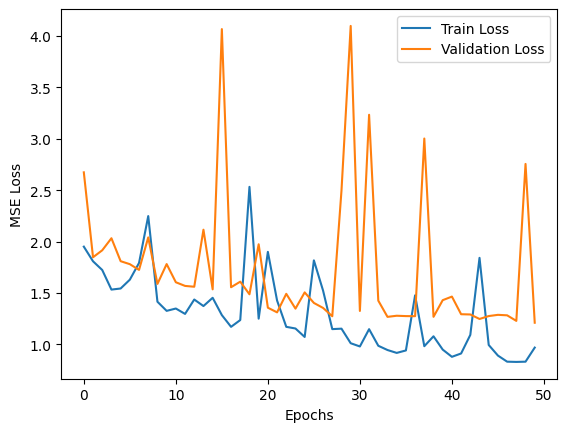

In [53]:
# implement your solution BELOW

loss_fn = torch.nn.MSELoss()
lr = 0.001
optimizer = torch.optim.Adam(reg_model.parameters(), lr)

train_losses = []
val_losses = [] 

epochs = 50
for epoch in range(epochs):
    reg_model.train()

    train_loss_sum = 0
    for inputs,labels in dataloader_reg_train:
        preds = reg_model(inputs)
        loss = loss_fn(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()
    
    val_loss_sum = 0
    reg_model.eval()
    with torch.no_grad():
        for val_inputs, val_labels in dataloader_reg_val:
            val_preds = reg_model(val_inputs)
            val_loss = loss_fn(val_preds, val_labels)
            val_loss_sum+=val_loss.item()

    train_losses.append(train_loss_sum / len(dataloader_reg_train))
    val_losses.append(val_loss_sum / len(dataloader_reg_val))


plt.plot(train_losses, label = "Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")


test_loss_sum = 0
reg_model.eval()

with torch.no_grad():
    for test_inputs, test_labels in dataloader_reg_test:
        test_preds = reg_model(test_inputs)
        test_loss = loss_fn(test_preds, test_labels)
        test_loss_sum+=test_loss.item()

    test_mse = test_loss_sum / len(dataloader_reg_test)

sample_inputs, sample_outputs = next(iter(dataloader_reg_test))
sample_preds = reg_model(sample_inputs)

for i in range(5):
    print(f"Predicted: {sample_preds[i].item():.2f}, Actual: {sample_outputs[i].item():.2f}")
# implement your solution ABOVE

tester.test('reg_model_learning', test_mse)

## **G**: Creating data iterators for the classification task

Similarly to task D, here we also need to create three data iterators. However, this time we will learn to solve a slightly different task, so the shapes / data types of the returned tensors will also differ. **Create** the **iterators** named `dataloader_cl_train`, `dataloader_cl_val`, and `dataloader_cl_test`, which should again traverse the arrays containing the training, validation, and test sets created in subtask C. In the classification task, we use all variables in the dataset as input variables except the students' three third-period grades (`G1`, `G2`, `G3`, the columns with indices #30, #31, and #32 in the original dataset text file). As labels, we define three categories and assign every student to one of them:
- **"Low-performing students"** category, category index #0: Students belong here if at least two of their grades are lower than 11.
- **"Moderately performing students"** category, category index #1: Students belong here if their average grade is lower than 14, but they do not belong to the "Low-performing students" category.
- **"High-performing students"** category, category index #2: Students belong here if they do not belong to either of the other two categories.

Based on the above, the tensors returned by the iterators will have shapes `(batch_size, 33)` and `(batch_size,)`. The latter tensor (containing the labels) will store the category indices of the students (that is, values 0, 1, or 2, with data type `torch.int64`), while the former will store the values of all used dataset variables for the corresponding samples with data type `torch.float32`. `batch_size` once again denotes the number of samples and must be set manually.

The iterators enumerating the **training and validation sets must traverse the corresponding samples in random order**. The iterator enumerating the test set must not change the order of the `dataset_split_test` array!


In [55]:
# implement your solution BELOW


class DatasetCE(Dataset):
    def __init__(self, arr):
        self.arr = torch.as_tensor(arr, dtype = torch.float32)

    def __len__(self):
        return self.arr.shape[0]
    
    def __getitem__(self, idx):
        grades = self.arr[idx, 30:33]
        input_tensor = torch.cat((self.arr[idx, :30], self.arr[idx, 33:]))
        if torch.count_nonzero(grades < 11) >= 2:
            label_tensor = torch.as_tensor(0, dtype=torch.int64)
        
        elif torch.mean(grades) < 14:
            label_tensor = torch.as_tensor(1, dtype = torch.int64)

        else:
            label_tensor = torch.as_tensor(2, dtype = torch.int64)
        
        return (input_tensor, label_tensor)


dataset_train = DatasetCE(dataset_split_train)
dataset_val = DatasetCE(dataset_split_val)
dataset_test = DatasetCE(dataset_split_test)


dataloader_cl_train = DataLoader(dataset_train, batch_size=32, shuffle = True)
dataloader_cl_val = DataLoader(dataset_val, batch_size=32, shuffle = True)
dataloader_cl_test = DataLoader(dataset_test, batch_size=32, shuffle = False)

# implement your solution ABOVE

tester.test('cl_iter', dataloader_cl_train, dataloader_cl_val, dataloader_cl_test)

Tester: Dataset iterators for classification task OK


## **H**: Defining the classification neural network

**Define the class implementing the neural network to be used for the classification task**, which, similarly to the class implementing the regression neural network, must be a subclass of the general `torch.nn.Module` class. Instantiate the new class and assign the instance to the variable `cl_model`!

The classification neural network must **contain 3 fully connected layers. The first two layers must contain 30 and 20 neurons, respectively, and apply the ReLU activation function after these layers.** The final layer must be designed for three-class classification!


In [59]:
# implement your solution BELOW


class customCE(torch.nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(input_size, 30),
            nn.ReLU(),
            nn.Linear(30, 20),
            nn.ReLU(),
            nn.Linear(20, num_classes)
        )

    def forward(self, x):
        return self.stack(x)
    
cl_features = dataset_train[0][0].shape[0]
cl_model = customCE(cl_features, 3)



# implement your solution ABOVE

tester.test('cl_model_architecture', cl_model)

Tester: Classification model architecture OK


## **I**: Training the network for the multi-class classification task

**Train the** `cl_model` **neural network** on the training set using the `dataloader_cl_train` iterator, and use the `dataloader_cl_val` iterator for validation!

Use the **cross-entropy (CE) loss**, which is commonly used in multi-class classification. **Measure the training and validation losses in every epoch, then after training plot how these values changed during training on a shared plot.** On the plot, again make sure that there is a legend and that the curves are easy to distinguish.

This time, training must be stopped using the **early stopping** technique. If the validation loss does not improve for a given number of epochs (`patience`), training should end, and **the weights of `cl_model` must be restored from the epoch in which the validation loss was best!** This must happen automatically.

After training, **measure the average loss on the full test set** and assign the resulting value to the variable `test_ce`!

**Also compute the _accuracy_ metric on the test set samples** and assign the resulting value to the variable `test_acc`!! The _accuracy_ metric gives the proportion of correctly classified samples. For example, if while predicting the categories of 150 samples we correctly identify the right category in 75 cases, then the value of _accuracy_ is 0.5.

After that, **select a few samples from the test set** (for example using the `dataloader_cl_test` iterator), and **predict their labels** (their category indices) based on the values of the input variables, then **print the predicted and true labels for each sample** (the category indices). This way, we can also see from examples how good the predictions of our neural network are.

Finally, **compute the confusion matrix of the network on the test set and plot it**! The confusion matrix is a k x k matrix for k categories, where the element at index `[i,j]` gives how many samples belonging to category `i` in the dataset were predicted by our model as category `j`. Good model performance is indicated when as many elements as possible fall on the main diagonal of the confusion matrix. For the computation, you may also use an external library, but it can be done in NumPy as well. For plotting, you may for example use the `imshow` function from `matplotlib.pyplot`. Make sure that it is clearly visible on the plot which axis lists the true categories and which lists the predicted categories, that the category indices are visible at the ends of the rows and columns, and that the cells contain the corresponding sample counts!


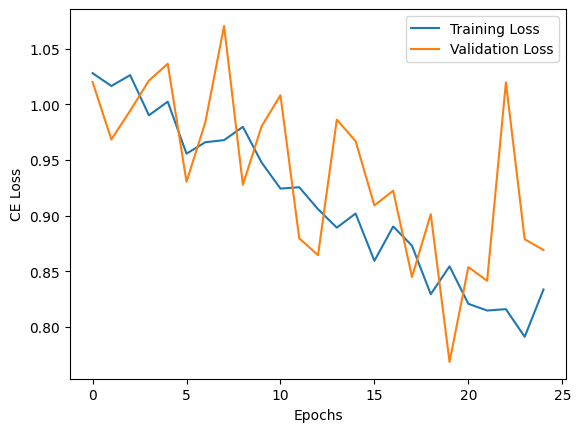

Predicted: 0, Actual: 1
Predicted: 2, Actual: 2
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 2, Actual: 2


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# implement your solution BELOW
loss_fn_cl = nn.CrossEntropyLoss()
optimizer_cl = torch.optim.Adam(cl_model.parameters(), lr = 0.001)

epochs = 100
train_losses = []
val_losses = []
patience = 5
best_val_loss = float('inf')
trigger_times = 0
best_weights = torch.zeros((cl_features))


for epoch in range(epochs):
    cl_model.train()

    train_loss_sum = 0
    for inputs,labels in dataloader_cl_train:
        preds = cl_model(inputs)
        loss = loss_fn_cl(preds, labels)
        optimizer_cl.zero_grad()
        loss.backward()
        optimizer_cl.step()
        train_loss_sum+=loss.item()

    val_loss_sum = 0
    cl_model.eval()
    with torch.no_grad():
        for val_inputs, val_outputs in dataloader_cl_val:
            val_preds = cl_model(val_inputs)
            val_loss = loss_fn_cl(val_preds, val_outputs)
            val_loss_sum+=val_loss.item()

    train_losses.append(train_loss_sum/len(dataloader_cl_train))
    current_val_loss = val_loss_sum/len(dataloader_cl_val)
    val_losses.append(current_val_loss)

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_weights = copy.deepcopy(cl_model.state_dict())
        trigger_times = 0

    else:
        trigger_times+=1
        if trigger_times >= patience:
            break



cl_model.load_state_dict(best_weights)

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("CE Loss")

plt.show()

test_loss_sum = 0
right_predicted = 0
all_preds = []
all_actuals = []

cl_model.eval()
with torch.no_grad():
    for test_inputs, test_outputs in dataloader_cl_test:
        test_preds = cl_model(test_inputs)
        test_loss = loss_fn_cl(test_preds, test_outputs)
        test_loss_sum+=test_loss.item()
        predicted_classes = torch.argmax(test_preds, dim = 1)
        all_preds.extend(predicted_classes.numpy())
        all_actuals.extend(test_outputs.numpy())
        right_predicted += torch.sum(predicted_classes == test_outputs).item()
    test_ce = test_loss_sum/len(dataloader_cl_test)
    test_acc = right_predicted / len(dataset_split_test)


sample_inputs, sample_outputs = next(iter(dataloader_cl_test))
sample_preds = cl_model(sample_inputs)
sample_pred_class = torch.argmax(sample_preds, dim = 1)

for i in range(5):
    print(f"Predicted: {sample_pred_class[i]:}, Actual: {sample_outputs[i].item():}")


conf_mtrx = np.zeros((3, 3), dtype=int)
for a, p in zip(all_actuals, all_preds):
    conf_mtrx[a, p] += 1

plt.imshow(conf_mtrx, cmap='Blues')
plt.xlabel("Predicted Categories")
plt.ylabel("Actual Categories")

plt.xticks([0,1,2])
plt.yticks([0,1,2])

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(conf_mtrx[i, j]), ha='center', va='center', color='black')

plt.show()
# implement your solution ABOVE

tester.test('cl_model_learning', test_ce, test_acc)